In [40]:
# Import Libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

In [39]:
# Load Dataset

heart_df = pd.read_csv("heart.csv")

In [8]:
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [11]:
heart_df.info()
heart_df.describe()
heart_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<Axes: xlabel='target', ylabel='count'>

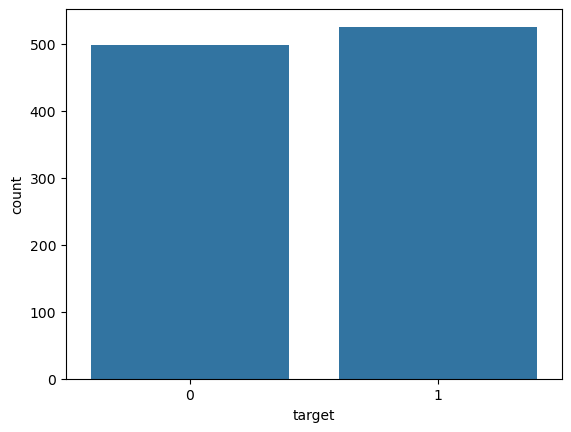

In [41]:
# Exploratory Data Analysis

sns.countplot(data=heart_df, x="target")

<Axes: xlabel='age', ylabel='Count'>

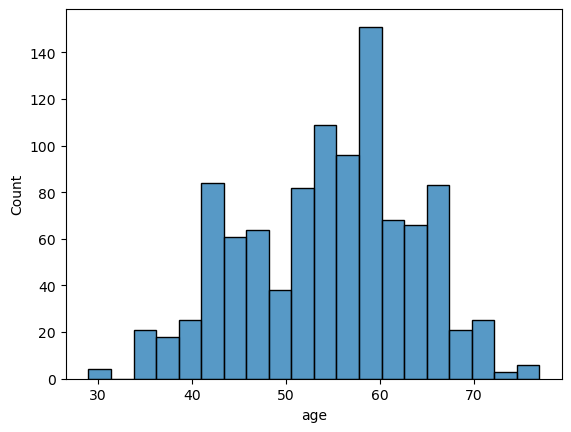

In [35]:
sns.histplot(
    data=heart_df,
    x="age",
    bins=20
)

<Axes: xlabel='cp', ylabel='count'>

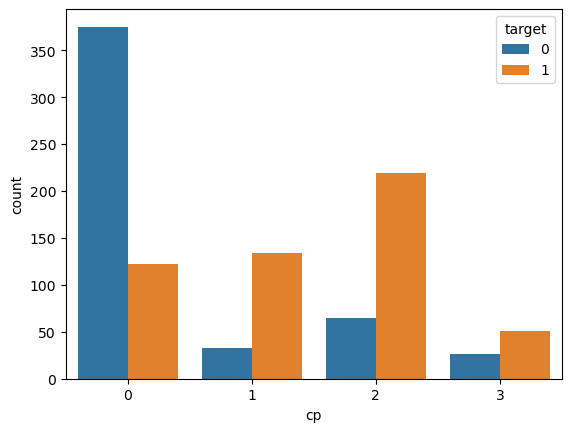

In [36]:
sns.countplot(
    data=heart_df,
    x="cp",
    hue="target"
)

<Axes: xlabel='target', ylabel='chol'>

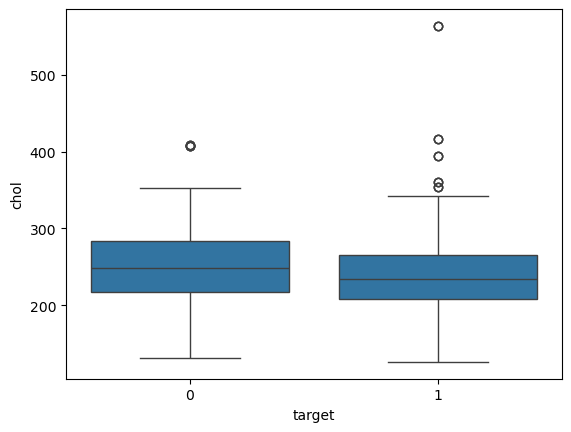

In [37]:
sns.boxplot(
    data=heart_df,
    x="target",
    y="chol"
)

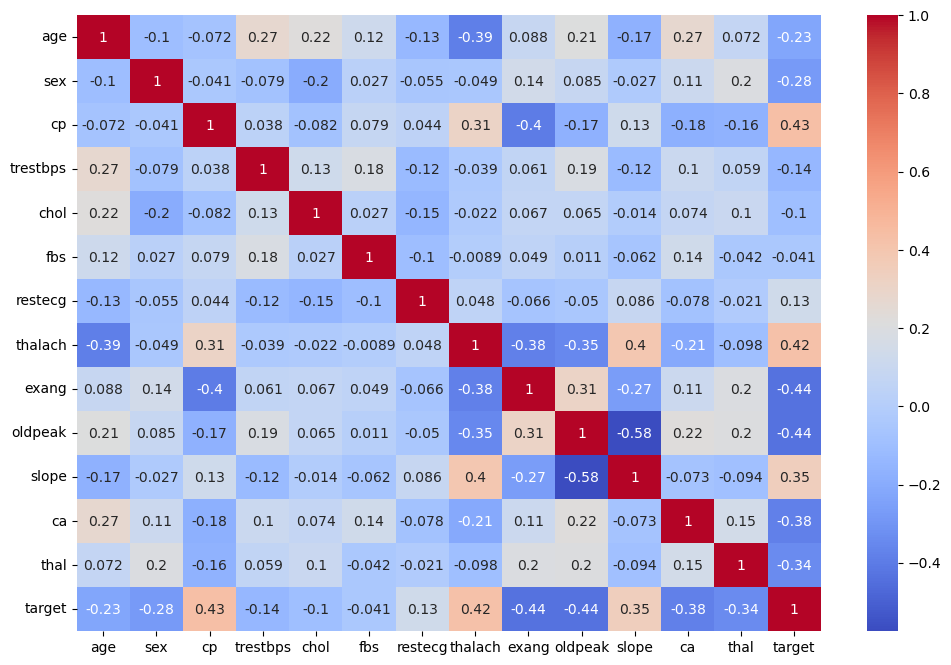

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    heart_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [13]:
X = heart_df.drop("target",axis=1)
y = heart_df["target"]

In [42]:
# Train Test Split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

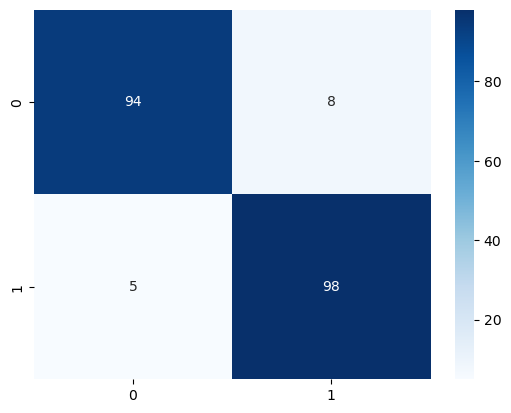

              precision    recall  f1-score   support

           0       0.95      0.92      0.94       102
           1       0.92      0.95      0.94       103

    accuracy                           0.94       205
   macro avg       0.94      0.94      0.94       205
weighted avg       0.94      0.94      0.94       205

Accuracy Score :  93.65853658536587
Precision Score :  92.45283018867924
Recall Score :  95.14563106796116
F1 Score :  93.77990430622009

Best Params :  {'knn__n_neighbors': 3}
Best Score :  89.14634146341463


In [46]:
# Pipeline

pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier())
])

param_grid = {"knn__n_neighbors" : [3,5,7,9]}

# Hyperparameter Tuning

classifierCV = GridSearchCV(
    pipeline,
    param_grid,
    cv = 5,
    scoring = "accuracy"
)

classifierCV.fit(X_train,y_train)
y_pred = classifierCV.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

# Model Evaluation

print(classification_report(y_test,y_pred))

print("Accuracy Score : ",accuracy_score(y_test,y_pred)*100)

print("Precision Score : ",precision_score(y_test,y_pred)*100)
print("Recall Score : ",recall_score(y_test,y_pred)*100)
print("F1 Score : ",f1_score(y_test,y_pred)*100)
print()
print("Best Params : ",classifierCV.best_params_)
print("Best Score : ",classifierCV.best_score_*100)